# Task 2: DenseNet-121

This notebook loads Notebook 1's prepared arrays and trains only DenseNet-121. Shared neural-network
augmentation, batching, checkpointing, recovery, and evaluation live in `src/task2_utils.py`.


## How to Run

Run `01_task2_setup.ipynb` first. Change the settings below if needed, then run this notebook.
It does not rerun setup or another model.


## 1. Setup


In [6]:
%matplotlib inline
import torch.nn as nn
from IPython.display import display


In [7]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from torchvision.models import densenet121
from src.task2_utils import (
    NeuralTrainer, ensure_task2_directories, model_checkpoint_path,
    neural_training_config, prepared_namespace, result_frame,
)
ensure_task2_directories()


### 1.1 Training configuration


In [ ]:
QUICK_RUN = False
RANDOM_STATE = 42
RESUME = False
ALLOW_CPU = False

# Editable DenseNet-121 hyperparameters. These override the shared defaults.
HYPERPARAMETERS = {
    "epochs": 30,
    "warmup_epochs": 4,
    "batch_size": 128,
    "patience": 5,

    "learning_rate": 1e-3,
    "weight_decay": 1.0e-3,

    "label_smoothing": 0.05,
    # 0.0 disables weighting; 0.5 uses square-root inverse training frequency.
    "class_weight_power": 0.0,

    "flip_probability": 0.5,
    "rotation_degrees": 12.0,
    "translate_fraction": 0.10,
    "jitter_strength": 0.05,

}

TRAINING_CONFIG = neural_training_config(
    quick_run=QUICK_RUN, random_state=RANDOM_STATE, resume=RESUME, allow_cpu=ALLOW_CPU,
)
TRAINING_CONFIG.update(HYPERPARAMETERS)
MODEL_CONFIG = {"architecture": "densenet121", "classifier_dropout": 0.40, **{
    key: value for key, value in TRAINING_CONFIG.items()
    if key not in {"resume", "allow_cpu", "keep_epoch_checkpoints"}
}}


## 2. Load Prepared Data and Shared Training Pipeline


In [9]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
trainer = NeuralTrainer(data, TRAINING_CONFIG)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")
print(f"Training batches per epoch: {len(trainer.train_loader)}")


Device: cuda | mixed precision: True | run fingerprint: 5f507c7bb57f
Loaded 30,260 train and 7,566 validation rows
Training batches per epoch: 237


## 3. Train DenseNet-121


DenseNet-121: /content/drive/MyDrive/Machine-Learning-Assignment-2/models/task2/checkpoints/model_densenet121.pt has an incompatible model configuration; training a compatible checkpoint
Training class weights: {'Fall': np.float64(0.729), 'Spring': np.float64(1.87), 'Summer': np.float64(0.54), 'Winter': np.float64(0.861)}
[DenseNet-121] starting epoch 1/30 (237 train + 15 validation batches)
[DenseNet-121] finished epoch 1/30 | train loss 1.1921 | val loss 1.0114 | train accuracy 0.5116 | val accuracy 0.5870 | macro-F1 0.5505 | best 0.5505 (epoch 1) | lr 5.00e-04 | 557s
[DenseNet-121] starting epoch 2/30 (237 train + 15 validation batches)
[DenseNet-121] finished epoch 2/30 | train loss 1.0852 | val loss 0.9465 | train accuracy 0.5770 | val accuracy 0.6318 | macro-F1 0.5906 | best 0.5906 (epoch 2) | lr 7.50e-04 | 557s
[DenseNet-121] starting epoch 3/30 (237 train + 15 validation batches)
[DenseNet-121] finished epoch 3/30 | train loss 1.0240 | val loss 0.9245 | train accuracy 0.6150 | 

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,DenseNet-121,0.742004,0.737306,0.728526,0.741683,0.926513


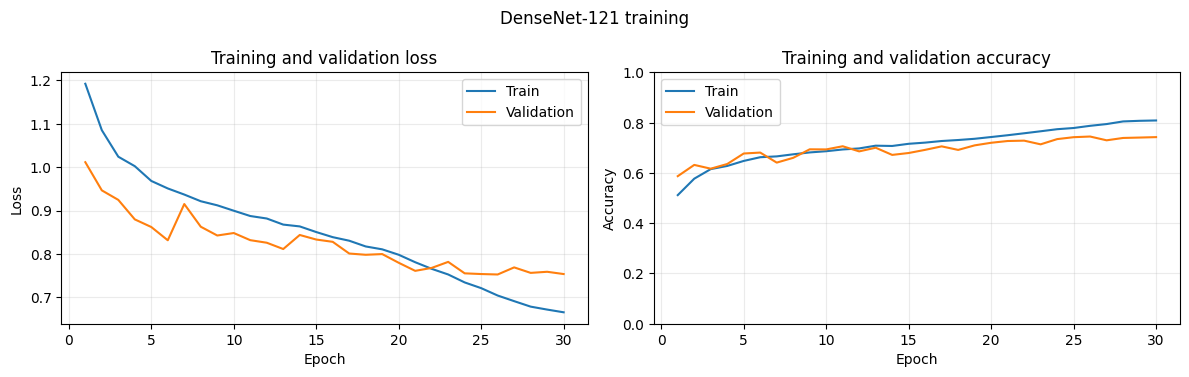

In [11]:
def build_model():
    model = densenet121(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(MODEL_CONFIG["classifier_dropout"]),
        nn.Linear(in_features, data.n_classes),
    )
    return model

densenet, history, logits = trainer.train_or_restore(
    "densenet121", build_model, "DenseNet-121", MODEL_CONFIG
)
predictions = logits.argmax(axis=1)
display(result_frame(data.y_val, predictions, logits, "DenseNet-121"))
trainer.plot_history(history, "DenseNet-121 training")


## 4. Export DenseNet-121 Results


In [12]:
print("Completed checkpoint:", model_checkpoint_path("densenet121"))
print("Run fingerprint:", data.fingerprint)


Completed checkpoint: /content/drive/MyDrive/Machine-Learning-Assignment-2/models/task2/checkpoints/model_densenet121.pt
Run fingerprint: 5f507c7bb57f
